<a href="https://colab.research.google.com/github/JavierAMLC/Laboratorio_UCV_RNN_Traductor_Ruso_Espanol/blob/main/Laboratorio_UCV_RNN_Traductor_Ruso_Espa%C3%B1ol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD CÉSAR VALLEJO
## Escuela Profesional de Ingeniería de Sistemas
### INFORME DE LABORATORIO: Traductor básico Ruso → Español usando RNN/LSTM
#### Alumno: Anderson Javier Musaja Lopez



### 1. Preparación del entorno

In [3]:
%pip install tensorflow pandas numpy matplotlib -q

### 2. Importar librerías y configurar semillas

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.20.0


### 3. Dataset Ampliado (Incluye el Dataset Base + 20 Frases del Reto MIT)

In [5]:
translation_pairs = [
    # --- Dataset Base Original ---
    ('привет', 'hola'),
    ('здравствуй', 'hola'),
    ('доброе утро', 'buenos días'),
    ('добрый день', 'buenas tardes'),
    ('добрый вечер', 'buenas noches'),
    ('спокойной ночи', 'buenas noches'),
    ('спасибо', 'gracias'),
    ('большое спасибо', 'muchas gracias'),
    ('пожалуйста', 'por favor'),
    ('извини', 'lo siento'),
    ('как дела', 'cómo estás'),
    ('я хорошо', 'estoy bien'),
    ('я плохо', 'estoy mal'),
    ('я устал', 'estoy cansado'),
    ('я голоден', 'tengo hambre'),
    ('я хочу воды', 'quiero agua'),
    ('я хочу есть', 'quiero comer'),
    ('где туалет', 'dónde está el baño'),
    ('сколько стоит', 'cuánto cuesta'),
    ('это дорого', 'esto es caro'),
    ('это дешево', 'esto es barato'),
    ('я student', 'soy estudiante'),
    ('я преподаватель', 'soy profesor'),
    ('я из перу', 'soy de perú'),
    ('ты говоришь по испански', 'hablas español'),
    ('я говорю по русски', 'hablo ruso'),
    ('я не понимаю', 'no entiendo'),
    ('повтори пожалуйста', 'repite por favor'),
    ('я тебя люблю', 'te quiero'),
    ('я скучаю по тебе', 'te extraño'),
    ('до свидания', 'adiós'),
    ('увидимся завтра', 'nos vemos mañana'),
    ('сегодня холодно', 'hoy hace frío'),
    ('сегодня жарко', 'hoy hace calor'),
    ('мне нравится музыка', 'me gusta la música'),
    ('мне нравится кофе', 'me gusta el café'),
    ('я люблю читать', 'me gusta leer'),
    ('я люблю путешествовать', 'me gusta viajar'),
    ('это мой друг', 'este es mi amigo'),
    ('это моя подруга', 'esta es mi amiga'),
    ('у меня есть вопрос', 'tengo una pregunta'),
    ('помоги мне', 'ayúdame'),
    ('открой дверь', 'abre la puerta'),
    ('закрой дверь', 'cierra la puerta'),
    ('я дома', 'estoy en casa'),
    ('я в университете', 'estoy en la universidad'),
    ('я работаю', 'estoy trabajando'),
    ('я учусь', 'estoy estudiando'),
    ('мне нужно идти', 'tengo que irme'),
    ('до завтра', 'hasta mañana'),

    # --- Reto MIT: 20 Frases Adicionales ---
    ('как тебя зовут', 'cómo te llamas'),
    ('меня зовут алекс', 'me llamo alex'),
    ('рад встрече', 'encantado de conocerte'),
    ('где ты живешь', 'dónde vives'),
    ('я живу в лиме', 'vivo en lima'),
    ('которое час', 'qué hora es'),
    ('я не знаю', 'no lo sé'),
    ('это отлично', 'esto es excelente'),
    ('мне нужна помощь', 'necesito ayuda'),
    ('я очень счастлив', 'estoy muy feliz'),
    ('какая сегодня погода', 'qué tiempo hace hoy'),
    ('я хочу спать', 'quiero dormir'),
    ('где находится станция', 'dónde está la estación'),
    ('это легко', 'esto es fácil'),
    ('это сложно', 'esto es difícil'),
    ('счастливого пути', 'buen viaje'),
    ('добро пожаловать', 'bienvenido'),
    ('увидимся позже', 'nos vemos luego'),
    ('я согласен', 'estoy de acuerdo'),
    ('это правда', 'es verdad')
]

df = pd.DataFrame(translation_pairs, columns=['ruso', 'espanol'])
print(f'Total de pares de traducción: {len(df)}')
df.head(10)

Total de pares de traducción: 70


,ruso,espanol
0,привет,hola
1,здравствуй,hola
2,доброе утро,buenos días
3,добрый день,buenas tardes
4,добрый вечер,buenas noches
5,спокойной ночи,buenas noches
6,спасибо,gracias
7,большое спасибо,muchas gracias
8,пожалуйста,por favor
9,извини,lo siento


### 4. Agregar tokens especiales

In [6]:
df['target_input'] = '<start> ' + df['espanol']
df['target_output'] = df['espanol'] + ' <end>'
df.head()

,ruso,espanol,target_input,target_output
0,привет,hola,<start> hola,hola <end>
1,здравствуй,hola,<start> hola,hola <end>
2,доброе утро,buenos días,<start> buenos días,buenos días <end>
3,добрый день,buenas tardes,<start> buenas tardes,buenas tardes <end>
4,добрый вечер,buenas noches,<start> buenas noches,buenas noches <end>


### 5. Tokenización

In [7]:
input_tokenizer = Tokenizer(filters='')
input_tokenizer.fit_on_texts(df['ruso'])

target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(pd.concat([df['target_input'], df['target_output']]))

input_sequences = input_tokenizer.texts_to_sequences(df['ruso'])
target_input_sequences = target_tokenizer.texts_to_sequences(df['target_input'])
target_output_sequences = target_tokenizer.texts_to_sequences(df['target_output'])

print('Ejemplo ruso tokenizado:', input_sequences[0])
print('Ejemplo español entrada tokenizado:', target_input_sequences[0])
print('Ejemplo español salida tokenizado:', target_output_sequences[0])

Ejemplo ruso tokenizado: [25]
Ejemplo español entrada tokenizado: [1, 19]
Ejemplo español salida tokenizado: [19, 2]


### 6. Padding (Relleno)

In [8]:
max_encoder_seq_length = max(len(seq) for seq in input_sequences)
max_decoder_seq_length = max(len(seq) for seq in target_input_sequences)

encoder_input_data = pad_sequences(input_sequences, maxlen=max_encoder_seq_length, padding='post')
decoder_input_data = pad_sequences(target_input_sequences, maxlen=max_decoder_seq_length, padding='post')
decoder_target_data = pad_sequences(target_output_sequences, maxlen=max_decoder_seq_length, padding='post')

num_encoder_tokens = len(input_tokenizer.word_index) + 1
num_decoder_tokens = len(target_tokenizer.word_index) + 1

print('Longitud máxima encoder:', max_encoder_seq_length)
print('Longitud máxima decoder:', max_decoder_seq_length)
print('Vocabulario ruso:', num_encoder_tokens)
print('Vocabulario español:', num_decoder_tokens)

Longitud máxima encoder: 4
Longitud máxima decoder: 5
Vocabulario ruso: 108
Vocabulario español: 111


### 7. Ajustar dimensión de salida esperada del Decoder

In [9]:
decoder_target_data = np.expand_dims(decoder_target_data, -1)
print('Forma de decoder_target_data:', decoder_target_data.shape)

Forma de decoder_target_data: (70, 5, 1)


### 8. Construcción del modelo Encoder–Decoder con LSTM

In [10]:
embedding_dim = 64
latent_dim = 128

# --- Encoder ---
encoder_inputs = Input(shape=(None,), name='encoder_inputs')
encoder_embedding = Embedding(
    input_dim=num_encoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='encoder_embedding'
)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
_, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# --- Decoder ---
decoder_inputs = Input(shape=(None,), name='decoder_inputs')
decoder_embedding_layer = Embedding(
    input_dim=num_decoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='decoder_embedding'
)
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name='decoder_lstm'
)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

# --- Compilación ---
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 64)  │      6,912 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 64)  │      7,104 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     98,816 │ decoder_embeddin… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 111) │     14,319 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 225,967 (882.68 KB)

 Trainable params: 225,967 (882.68 KB)

 Non-trainable params: 0 (0.00 B)

### 9. Entrenamiento del Modelo

In [11]:
print('Iniciando entrenamiento...')
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=8,
    epochs=300,
    validation_split=0.2,
    verbose=1
)
print('Entrenamiento finalizado.')

Iniciando entrenamiento...
Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.2113 - loss: 4.6999 - val_accuracy: 0.2692 - val_loss: 4.6877
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2887 - loss: 4.6551 - val_accuracy: 0.2692 - val_loss: 4.6370
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2887 - loss: 4.5394 - val_accuracy: 0.2692 - val_loss: 4.4630
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2887 - loss: 4.1267 - val_accuracy: 0.2692 - val_loss: 3.9431
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2887 - loss: 3.7023 - val_accuracy: 0.2692 - val_loss: 4.1159
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2887 - loss: 3.6113 - val_accuracy: 0.2692 - val_loss: 4.0629
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2887 - loss: 3.5209 - val_accuracy: 0.2692 - val_loss: 4.0999
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2887 - loss: 3.4756 - val

### 10. Visualizar curvas de pérdida y precisión

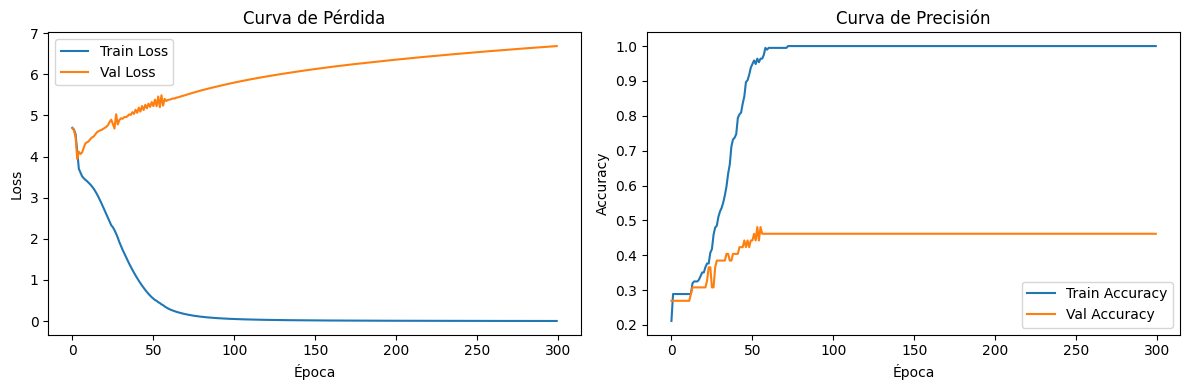

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 11. Construcción de Modelos de Inferencia

In [13]:
# Modelo encoder para inferencia
encoder_model = Model(encoder_inputs, encoder_states)

# Modelo decoder para inferencia
decoder_state_input_h = Input(shape=(latent_dim,), name='decoder_state_input_h')
decoder_state_input_c = Input(shape=(latent_dim,), name='decoder_state_input_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='decoder_input_single')
decoder_embedding_single = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs_single, state_h_single, state_c_single = decoder_lstm(
    decoder_embedding_single,
    initial_state=decoder_states_inputs
)
decoder_states_single = [state_h_single, state_c_single]
decoder_outputs_single = decoder_dense(decoder_outputs_single)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs_single] + decoder_states_single
)

### 12. Función de Inferencia / Traducción

In [14]:
reverse_target_word_index = {index: word for word, index in target_tokenizer.word_index.items()}
start_token = target_tokenizer.word_index['<start>']
end_token = target_tokenizer.word_index['<end>']

def translate(sentence):
    sequence = input_tokenizer.texts_to_sequences([sentence])
    sequence = pad_sequences(sequence, maxlen=max_encoder_seq_length, padding='post')

    states_value = encoder_model.predict(sequence, verbose=0)
    target_sequence = np.array([[start_token]])
    translated_words = []

    for _ in range(max_decoder_seq_length):
        output_tokens, h, c = decoder_model.predict([target_sequence] + states_value, verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        if sampled_token_index == end_token:
            break

        sampled_word = reverse_target_word_index.get(sampled_token_index, '')
        if sampled_word:
            translated_words.append(sampled_word)

        target_sequence = np.array([[sampled_token_index]])
        states_value = [h, c]

    return ' '.join(translated_words)

### 13. Pruebas con frases del Dataset de Entrenamiento

In [15]:
test_sentences = [
    'привет',
    'спасибо',
    'я тебя люблю',
    'доброе утро',
    'я студент',
    'я не понимаю'
]

print('--- Pruebas Internas ---')
for sentence in test_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

--- Pruebas Internas ---
привет  ->  hola
спасибо  ->  gracias
я тебя люблю  ->  te quiero
доброе утро  ->  buenos días
я студент  ->  
я не понимаю  ->  no entiendo


### 14. Pruebas con frases fuera del Dataset (Evaluación de Generalización)

In [16]:
new_sentences = [
    'я люблю кофе',
    'ты студент',
    'мне нравится русский'
]

print('--- Pruebas Externas ---')
for sentence in new_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

--- Pruebas Externas ---
я люблю кофе  ->  me gusta viajar
ты студент  ->  por favor
мне нравится русский  ->  estoy mal


### 15. Guardar el Modelo

In [17]:
model.save('russian_spanish_seq2seq_lstm.keras')
print('Modelo serializado correctamente.')

Modelo serializado correctamente.
